# DivLearn Encoder Analysis: Estimated vs. Actual KL

This notebook analyzes whether the **DivLearn transformer encoder** learned a semantically meaningful similarity over actions.

During training (`SACAgentDivLearn.update_encoder`), the encoder is fit so that

$$\log\frac{z(a_1)\cdot z(a_2) + 1}{2} \;\approx\; \frac{\log \pi(a_2 \mid s)}{\kappa_{\text{kl}}}$$

where the inner product is between L2-normalized encodings, $a_1$ is a policy sample at state $s$, $a_2$ is the action being scored, and $\kappa_{\text{kl}} = 20$ is `kl_scale` in `SACAgentDivLearn`. The right-hand side is clamped to $[-10, 0]$ during training, so the encoder can only approximate the target within that band.

**Test procedure (noisy-perturbation probe):**

1. Sample expert $(s, a_\text{expert})$ pairs from the Minari dataset.
2. Perturb each expert action with Gaussian noise at varying magnitudes $\sigma \in \{0.0, 0.05, 0.1, 0.25, 0.5, 1.0\}$.
3. Compute **actual** $= \log \pi(a_2 \mid s)/\kappa_{\text{kl}}$ under the *trained* policy (where $a_2 = a_\text{expert} + \sigma \cdot \varepsilon$).
4. Compute **estimated** $= \log\,\mathrm{sim}(z(a_1), z(a_2))$ using the encoder, with $a_1 = a_\text{expert}$.
5. Compare the **trained** encoder to a freshly-initialized **untrained** encoder of the same architecture &mdash; this tells us what the relationship looks like *before* learning.

**Notebook structure:**

- **Section 1**: Imports, config (model checkpoint path is here), model loading.
- **Section 2**: Sample data and compute actual / estimated KL surrogates.
- **Section 3**: Scatter plots, residual histograms, and per-noise summary.

## Section 1 &mdash; Setup, config, and model loading

Edit the **CONFIG** block below to point at a different checkpoint or change the
encoder architecture if you trained with different hyperparameters. The defaults
correspond to the `DivLearn-Transformer-Same/log_target` run:

```
--encoder-type transformer
--encoder-kwargs '{"d_model":32,"out_dim":17,"num_layers":2,"num_heads":2}'
--kappa 0.01  --dl-base-lr 1e-2  --dl-lr-cap 1e-2  --bc-ramp-scale 1000
```

In [16]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


_here = Path.cwd().resolve()
for _root in (_here, *_here.parents):
    if (_root / "src").is_dir() and (_root / "pyproject.toml").is_file():
        PROJECT_ROOT = _root
        break
else:
    raise RuntimeError("Could not locate project root (looking for src/ + pyproject.toml).")
_src_str = str(PROJECT_ROOT / "src")
if _src_str not in sys.path:
    sys.path.insert(0, _src_str)
print(f"Project root: {PROJECT_ROOT}")

from encoders.transformer_encoder import TransformerEncoder
from networks.rl_networks import Policy
from infrastructure import pytorch_util as ptu

Project root: /Users/kgillsp/Desktop/classes/cs285/cs285project


In [17]:
# ============================== CONFIG =======================================
AGENT_CHECKPOINT = PROJECT_ROOT / "modal_exp_tavish/DivLearn-Transformer-Same/log_target/agent.pt"
MINARI_DATASET_ID = "mujoco/humanoid/expert-v0"

OBS_DIM = 348
ACTION_DIM = 17

ENCODER_KWARGS = dict(d_model=32, out_dim=17, num_layers=2, num_heads=2)
ACTOR_KWARGS = dict(n_layers=6, layer_size=512, use_tanh=True, state_dependent_std=True)

KL_SCALE = 20.0
KL_TARGET_LOW, KL_TARGET_HIGH = -10.0, 0.0
ACT_EPS = 1e-3

NUM_SAMPLES_PER_NOISE = 1024
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]
SEED = 0
USE_GPU = torch.cuda.is_available()
# ==============================================================================

ptu.init_gpu(use_gpu=USE_GPU, gpu_id=0)
print(f"Device:      {ptu.device}")
print(f"Checkpoint:  {AGENT_CHECKPOINT}")
assert AGENT_CHECKPOINT.is_file(), f"Checkpoint not found: {AGENT_CHECKPOINT}"

Using CPU.
Device:      cpu
Checkpoint:  /Users/kgillsp/Desktop/classes/cs285/cs285project/modal_exp_tavish/DivLearn-Transformer-Same/log_target/agent.pt


In [18]:
def build_encoder() -> TransformerEncoder:
    return TransformerEncoder(
        action_dim=ACTION_DIM, obs_dim=OBS_DIM, **ENCODER_KWARGS,
    ).to(ptu.device)


def build_actor() -> Policy:
    return Policy(
        ac_dim=ACTION_DIM, ob_dim=OBS_DIM, discrete=False, **ACTOR_KWARGS,
    ).to(ptu.device)


def filter_prefix(state_dict: dict, prefix: str) -> dict:
    return {k[len(prefix):]: v for k, v in state_dict.items() if k.startswith(prefix)}


try:
    full_state = torch.load(AGENT_CHECKPOINT, map_location=ptu.device, weights_only=True)
except TypeError:
    full_state = torch.load(AGENT_CHECKPOINT, map_location=ptu.device)
print(f"Loaded full state_dict with {len(full_state)} tensors.")
print("Key prefixes present:", sorted({k.split('.')[0] for k in full_state}))

torch.manual_seed(SEED)
np.random.seed(SEED)

trained_encoder = build_encoder()
encoder_state = filter_prefix(full_state, "encoder.")
trained_encoder.load_state_dict(encoder_state, strict=True)
trained_encoder.eval()
print(f"Trained encoder: loaded {len(encoder_state)} parameter tensors.")

actor = build_actor()
actor_state = filter_prefix(full_state, "actor.")
actor.load_state_dict(actor_state, strict=True)
actor.eval()
print(f"Actor: loaded {len(actor_state)} parameter tensors.")

with torch.random.fork_rng(devices=[]):
    torch.manual_seed(SEED + 1)
    untrained_encoder = build_encoder()
untrained_encoder.eval()
print("Untrained encoder: freshly initialized (same architecture, seed=SEED+1).")

Loaded full state_dict with 100 tensors.
Key prefixes present: ['actor', 'beta', 'critic', 'encoder', 'target_critic']
Trained encoder: loaded 29 parameter tensors.
Actor: loaded 14 parameter tensors.
Untrained encoder: freshly initialized (same architecture, seed=SEED+1).


## Section 2 &mdash; Analysis

For each sampled $(s, a_\text{expert})$ pair and each noise scale $\sigma$:

- $a_2 \;=\; \mathrm{clip}\!\big(a_\text{expert} + \sigma \cdot \varepsilon,\; -1 + \texttt{ACT\_EPS},\; 1 - \texttt{ACT\_EPS}\big),\quad \varepsilon \sim \mathcal{N}(0, I)$
- **actual** $\;=\; \mathrm{clip}\big(\log \pi(a_2 \mid s) / \kappa_{\text{kl}},\; -10,\; 0\big)$ &nbsp; (trained tanh-Gaussian policy)
- **estimated (trained)** $\;=\; \log\,\mathrm{sim}\!\big(z_\theta(a_\text{expert}),\; z_\theta(a_2)\big)$
- **estimated (untrained)** $\;=\; \log\,\mathrm{sim}\!\big(z_{\theta_0}(a_\text{expert}),\; z_{\theta_0}(a_2)\big)$

If the encoder learned something semantically meaningful, the **trained** estimate should track the actual log-prob target much more closely than the **untrained** baseline.

In [20]:
import minari

print(f"Loading Minari dataset: {MINARI_DATASET_ID}")
md = minari.load_dataset(MINARI_DATASET_ID, download=True)

obs_chunks, act_chunks = [], []
for ep in md.iterate_episodes():
    obs_chunks.append(ep.observations[:-1].astype(np.float32))
    act_chunks.append(ep.actions.astype(np.float32))
all_obs = np.concatenate(obs_chunks, axis=0)
all_acts = np.concatenate(act_chunks, axis=0)
print(f"Total transitions: {len(all_obs):,}  (obs_dim={all_obs.shape[1]}, action_dim={all_acts.shape[1]})")

assert all_obs.shape[1] == OBS_DIM, f"obs_dim mismatch: dataset={all_obs.shape[1]}, config={OBS_DIM}"
assert all_acts.shape[1] == ACTION_DIM, f"action_dim mismatch: dataset={all_acts.shape[1]}, config={ACTION_DIM}"

rng = np.random.default_rng(SEED)
idx = rng.choice(len(all_obs), size=NUM_SAMPLES_PER_NOISE, replace=False)
obs_np = all_obs[idx]
act_np = all_acts[idx]

print(f"Sampled {NUM_SAMPLES_PER_NOISE} (s, a) pairs (same base set is perturbed at every noise level).")
print(f"Expert action range:  min={act_np.min():.3f}, max={act_np.max():.3f}, "
      f"|mean|={np.abs(act_np).mean():.3f}, std={act_np.std():.3f}")

Loading Minari dataset: mujoco/humanoid/expert-v0



Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]


Dataset mujoco/humanoid/expert-v0 downloaded to /Users/kgillsp/.minari/datasets/mujoco/humanoid/expert-v0
Total transitions: 999,434  (obs_dim=348, action_dim=17)
Sampled 1024 (s, a) pairs (same base set is perturbed at every noise level).
Expert action range:  min=-0.400, max=0.400, |mean|=0.305, std=0.319


In [21]:
@torch.no_grad()
def encoder_log_sim(encoder: torch.nn.Module, a1: torch.Tensor, a2: torch.Tensor) -> torch.Tensor:
    """log((normalize(z(a1)) . normalize(z(a2)) + 1) / 2) -- the encoder's KL surrogate."""
    z1 = F.normalize(encoder(a1), dim=-1)
    z2 = F.normalize(encoder(a2), dim=-1)
    dot = (z1 * z2).sum(dim=-1)
    sim = ((dot + 1.0) / 2.0).clamp(min=1e-6)
    return torch.log(sim)


@torch.no_grad()
def policy_log_prob(obs: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
    """log pi(a | s) under the trained tanh-Gaussian policy (with the same ACT_EPS clip as training)."""
    dist = actor(obs)
    actions_safe = actions.clamp(-1.0 + ACT_EPS, 1.0 - ACT_EPS)
    return dist.log_prob(actions_safe)


obs_t = torch.as_tensor(obs_np, dtype=torch.float32, device=ptu.device)
act_t = torch.as_tensor(act_np, dtype=torch.float32, device=ptu.device)

records = []
torch.manual_seed(SEED)

for eps in NOISE_LEVELS:
    noise = torch.zeros_like(act_t) if eps == 0.0 else eps * torch.randn_like(act_t)
    perturbed = (act_t + noise).clamp(-1.0 + ACT_EPS, 1.0 - ACT_EPS)

    est_trained = encoder_log_sim(trained_encoder, act_t, perturbed)
    est_untrained = encoder_log_sim(untrained_encoder, act_t, perturbed)

    log_pi = policy_log_prob(obs_t, perturbed)
    actual = (log_pi / KL_SCALE).clamp(min=KL_TARGET_LOW, max=KL_TARGET_HIGH)

    records.append({
        "noise": float(eps),
        "actual": actual.detach().cpu().numpy(),
        "est_trained": est_trained.detach().cpu().numpy(),
        "est_untrained": est_untrained.detach().cpu().numpy(),
        "raw_log_pi": log_pi.detach().cpu().numpy(),
    })

arr_noise = np.concatenate([np.full_like(r["actual"], r["noise"]) for r in records])
arr_actual = np.concatenate([r["actual"] for r in records])
arr_trained = np.concatenate([r["est_trained"] for r in records])
arr_untrained = np.concatenate([r["est_untrained"] for r in records])
arr_log_pi = np.concatenate([r["raw_log_pi"] for r in records])

print(f"Collected {len(arr_actual):,} (sample x noise) data points.")
print(f"actual           range: [{arr_actual.min():+.3f}, {arr_actual.max():+.3f}]")
print(f"trained estimate range: [{arr_trained.min():+.3f}, {arr_trained.max():+.3f}]")
print(f"untrained estim. range: [{arr_untrained.min():+.3f}, {arr_untrained.max():+.3f}]")
print(f"raw log pi (unscaled, pre-clamp): "
      f"mean={arr_log_pi.mean():+.2f}, min={arr_log_pi.min():+.2f}, max={arr_log_pi.max():+.2f}")

Collected 6,144 (sample x noise) data points.
actual           range: [-10.000, +0.000]
trained estimate range: [-0.000, +0.000]
untrained estim. range: [-0.045, +0.000]
raw log pi (unscaled, pre-clamp): mean=-1400.13, min=-81780.83, max=+39.45


## Section 3 &mdash; Plots

- **Scatter (estimated vs actual)** with the $y=x$ diagonal &mdash; one panel each for the untrained ("before learning") and trained ("after learning") encoder. Points are colored by noise level so you can see how each scale clusters.
- **Residual histogram** of `estimated - actual`, overlaying trained and untrained.
- **Per-noise summary table** with Pearson correlation and RMSE.

If the trained encoder has learned a meaningful surrogate, the trained scatter should hug the diagonal much more tightly, residuals should concentrate near 0, and the trained Pearson $r$ should be substantially above the untrained baseline (especially when pooled across noise levels).

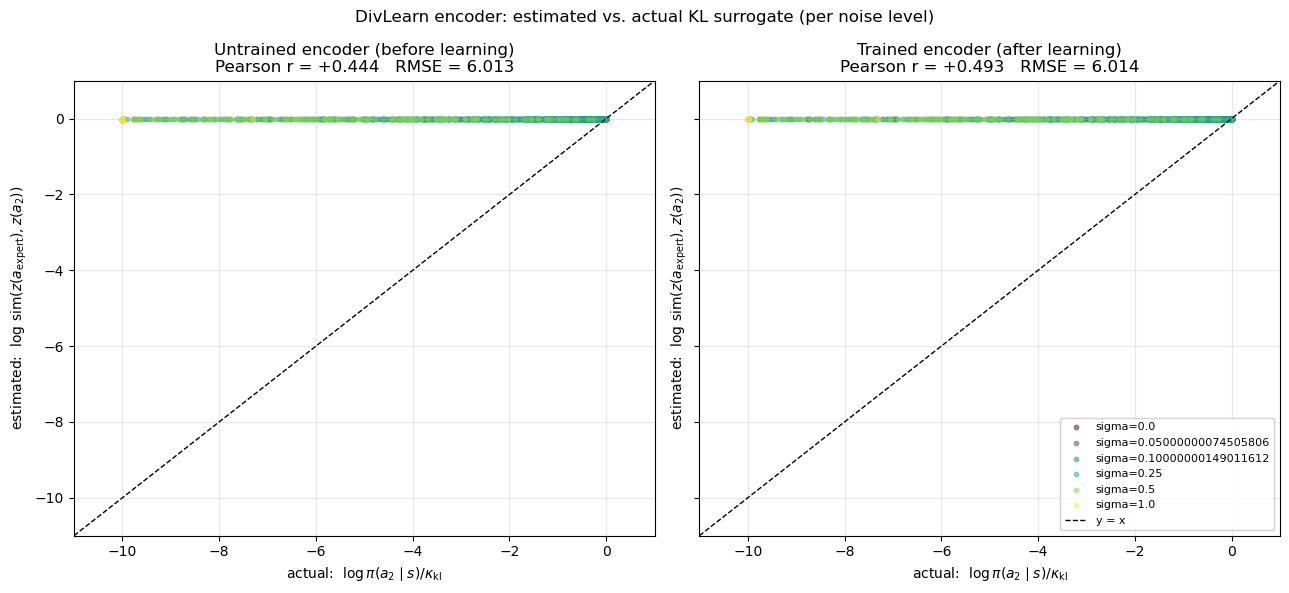

In [22]:
def pearson(x: np.ndarray, y: np.ndarray) -> float:
    if x.size < 2 or x.std() == 0 or y.std() == 0:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])


def rmse(x: np.ndarray, y: np.ndarray) -> float:
    return float(np.sqrt(((x - y) ** 2).mean()))


fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

unique_noise = sorted(set(arr_noise.tolist()))
cmap = plt.get_cmap("viridis")
noise_to_color = {
    eps: cmap(i / max(1, len(unique_noise) - 1)) for i, eps in enumerate(unique_noise)
}

lo = float(min(arr_actual.min(), arr_trained.min(), arr_untrained.min()))
hi = float(max(arr_actual.max(), arr_trained.max(), arr_untrained.max()))
pad = 0.1 * (hi - lo)
lo, hi = lo - pad, hi + pad

for ax, est, title in (
    (axes[0], arr_untrained, "Untrained encoder (before learning)"),
    (axes[1], arr_trained,   "Trained encoder (after learning)"),
):
    for eps in unique_noise:
        mask = arr_noise == eps
        ax.scatter(
            arr_actual[mask], est[mask],
            s=10, alpha=0.45, color=noise_to_color[eps],
            label=f"sigma={eps}",
        )
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
    r = pearson(arr_actual, est)
    rms = rmse(arr_actual, est)
    ax.set_title(f"{title}\nPearson r = {r:+.3f}   RMSE = {rms:.3f}")
    ax.set_xlabel(r"actual:  $\log \pi(a_2\mid s) / \kappa_{\rm kl}$")
    ax.set_ylabel(r"estimated:  $\log\,\mathrm{sim}(z(a_\mathrm{expert}), z(a_2))$")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.grid(alpha=0.3)

axes[1].legend(loc="lower right", fontsize=8, framealpha=0.9)
fig.suptitle("DivLearn encoder: estimated vs. actual KL surrogate (per noise level)")
fig.tight_layout()
plt.show()

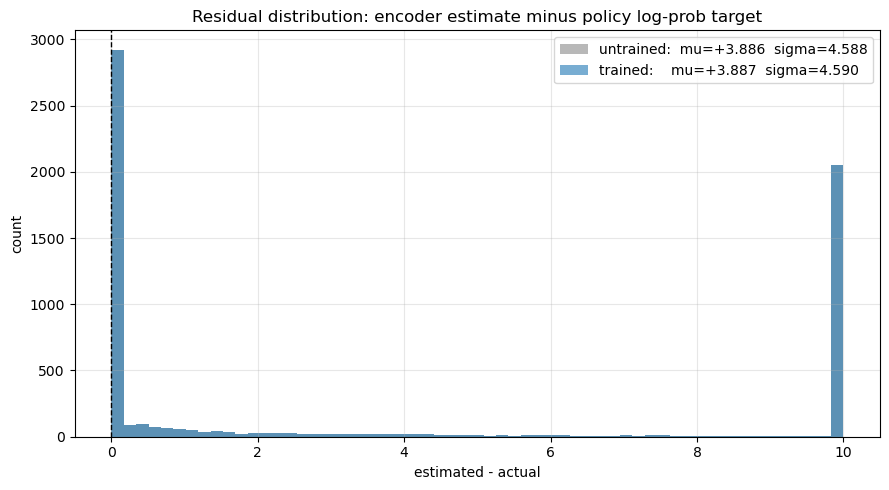

In [23]:
resid_untrained = arr_untrained - arr_actual
resid_trained = arr_trained - arr_actual

bins = np.linspace(
    float(min(resid_untrained.min(), resid_trained.min())),
    float(max(resid_untrained.max(), resid_trained.max())),
    60,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    resid_untrained, bins=bins, alpha=0.55, color="tab:gray",
    label=f"untrained:  mu={resid_untrained.mean():+.3f}  sigma={resid_untrained.std():.3f}",
)
ax.hist(
    resid_trained, bins=bins, alpha=0.6, color="tab:blue",
    label=f"trained:    mu={resid_trained.mean():+.3f}  sigma={resid_trained.std():.3f}",
)
ax.axvline(0.0, color="k", linestyle="--", lw=1)
ax.set_xlabel("estimated - actual")
ax.set_ylabel("count")
ax.set_title("Residual distribution: encoder estimate minus policy log-prob target")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

In [24]:
header = f"{'sigma':>8} | {'r (trained)':>12} | {'r (untrained)':>14} | {'RMSE trained':>13} | {'RMSE untrained':>15}"
print("=" * len(header))
print(header)
print("-" * len(header))
for eps in unique_noise:
    mask = arr_noise == eps
    a = arr_actual[mask]
    r_t = pearson(a, arr_trained[mask])
    r_u = pearson(a, arr_untrained[mask])
    rms_t = rmse(a, arr_trained[mask])
    rms_u = rmse(a, arr_untrained[mask])
    print(f"{eps:>8.3f} | {r_t:>+12.4f} | {r_u:>+14.4f} | {rms_t:>13.4f} | {rms_u:>15.4f}")
print("-" * len(header))
print(
    f"{'pooled':>8} | {pearson(arr_actual, arr_trained):>+12.4f} | "
    f"{pearson(arr_actual, arr_untrained):>+14.4f} | "
    f"{rmse(arr_actual, arr_trained):>13.4f} | {rmse(arr_actual, arr_untrained):>15.4f}"
)
print("=" * len(header))

   sigma |  r (trained) |  r (untrained) |  RMSE trained |  RMSE untrained
--------------------------------------------------------------------------
   0.000 |         +nan |           +nan |        0.0000 |          0.0000
   0.050 |      +0.0599 |        +0.0786 |        0.1496 |          0.1496
   0.100 |      +0.0960 |        +0.0515 |        1.3333 |          1.3333
   0.250 |      +0.2445 |        +0.0415 |        5.3252 |          5.3248
   0.500 |      +0.0952 |        +0.0351 |        9.3235 |          9.3214
   1.000 |      +0.0184 |        +0.0242 |        9.9977 |          9.9929
--------------------------------------------------------------------------
  pooled |      +0.4930 |        +0.4441 |        6.0144 |          6.0125
